$Name:$ $Mukaila$ $Rafiu$

$School:$ $Northeastern$ $University$

$Project:$ $Investigating$  $Gender$  $Bias$  $in$  $Graduate$  $Admissions$  $at$  $UC$  $Berkeley$  $(1973)$ 

In this causal analysis, we examine whether gender bias existed in graduate school admissions at University of California, Berkeley in 1973.

Description:
The dataset contains admission outcomes for six majors during the Fall 1973 admission cycle. This dataset is widely used in statistics 
and econometrics as a classic example of Simpson’s paradox, where an aggregate pattern reverses when the data are disaggregated into subgroups.

Data from: https://vincentarelbundock.github.io/Rdatasets/datasets.html 

Data name: Gender bias among graduate school admissions to UC Berkeley.

In [8]:
#Load Packages
import pandas as pd
import numpy as np
import datetime as dt
import pyfixest as pf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from scipy import stats
import statsmodels.api as sm

In [9]:
#load data
df = pd.read_csv("C://Users//Mukaila Rafiu//Downloads//admissions.csv")
df

,rownames,major,gender,admitted,applicants
0,1,A,men,62,825
1,2,B,men,63,560
2,3,C,men,37,325
3,4,D,men,33,417
4,5,E,men,28,191
5,6,F,men,6,373
6,7,A,women,82,108
7,8,B,women,68,25
8,9,C,women,34,593
9,10,D,women,35,375


In [10]:
df.shape

(12, 5)

In [11]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
dtype: bool

In [12]:
df.dtypes

rownames       int64
major         object
gender        object
admitted       int64
applicants     int64
dtype: object

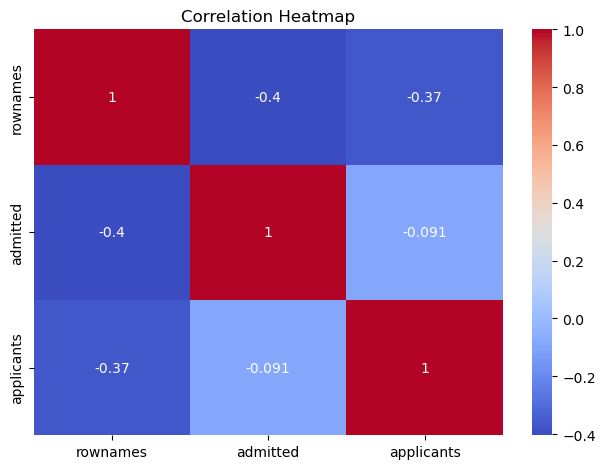

In [13]:
#Correlation heatmap
df1 = df.select_dtypes(include='number').copy()

sns.heatmap(df1.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()

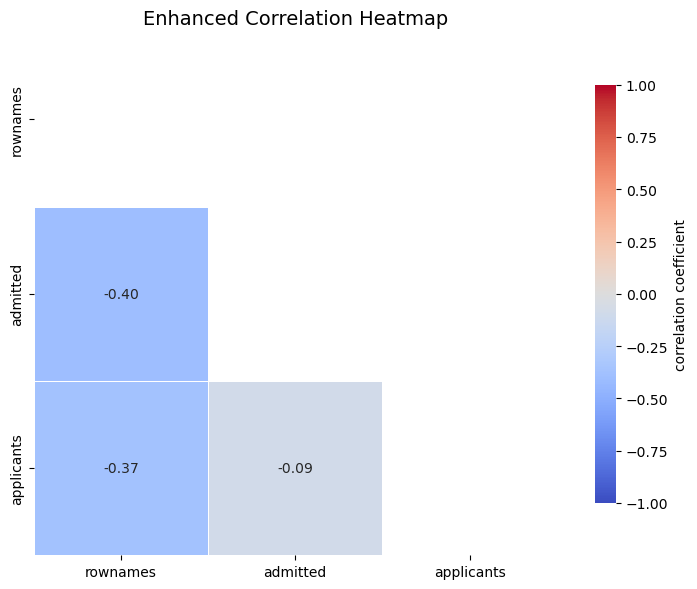

In [15]:
#Enhanced Correlation heatmap
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix,
            annot=True,
            mask=mask,
            cmap='coolwarm',
           vmin=-1, vmax=1,
           center=0,
           square=True,
           linewidths= .5,
           fmt='.2f',
           cbar_kws={'shrink': .8, 'label': 'correlation coefficient'})

plt.title("Enhanced Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
# Calculate number admitted and rejected
df['admitted_count'] = (df['admitted'] / 100 * df['applicants']).astype(int)
df['rejected_count'] = df['applicants'] - df['admitted_count']
df

,rownames,major,gender,admitted,applicants,admitted_count,rejected_count
0,1,A,men,62,825,511,314
1,2,B,men,63,560,352,208
2,3,C,men,37,325,120,205
3,4,D,men,33,417,137,280
4,5,E,men,28,191,53,138
5,6,F,men,6,373,22,351
6,7,A,women,82,108,88,20
7,8,B,women,68,25,17,8
8,9,C,women,34,593,201,392
9,10,D,women,35,375,131,244


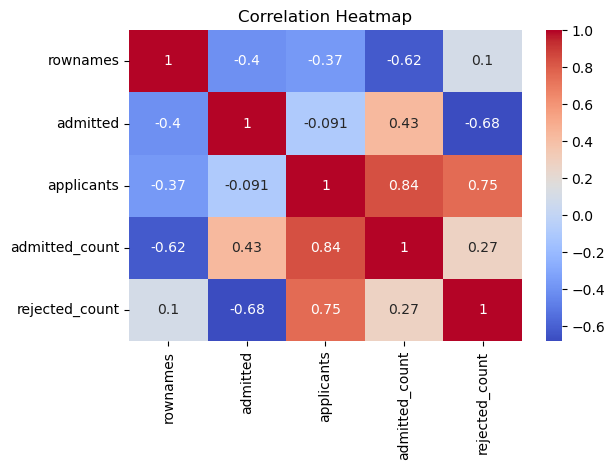

In [18]:
#Correlation heatmap
df2 = df.select_dtypes(include='number').copy()

sns.heatmap(df2.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()

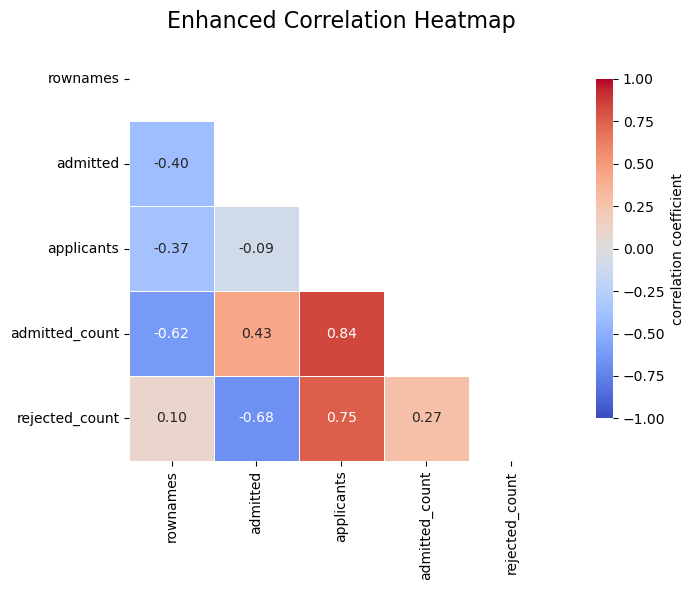

In [19]:
#Enhanced Correlation heatmap
correlation_matrix2 = df2.corr()
plt.figure(figsize=(9,6))
mask = np.triu(correlation_matrix2)
sns.heatmap(correlation_matrix2,
            annot=True,
            mask=mask,
            cmap='coolwarm',
           vmin=-1, vmax=1,
           center=0,
           square=True,
           linewidths= .5,
           fmt='.2f',
           cbar_kws={'shrink': .8, 'label': 'correlation coefficient'})

plt.title("Enhanced Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

In [20]:
#Overall rates ignoring major
overall_rates = df.groupby('gender').agg({'admitted_count': 'sum', 'applicants': 'sum'})
overall_rates['admission_rate'] = (overall_rates['admitted_count'] / overall_rates['applicants'] * 100).round(2)
print(overall_rates[['applicants', 'admitted_count', 'admission_rate']])

        applicants  admitted_count  admission_rate
gender                                            
men           2691            1195           44.41
women         1835             554           30.19


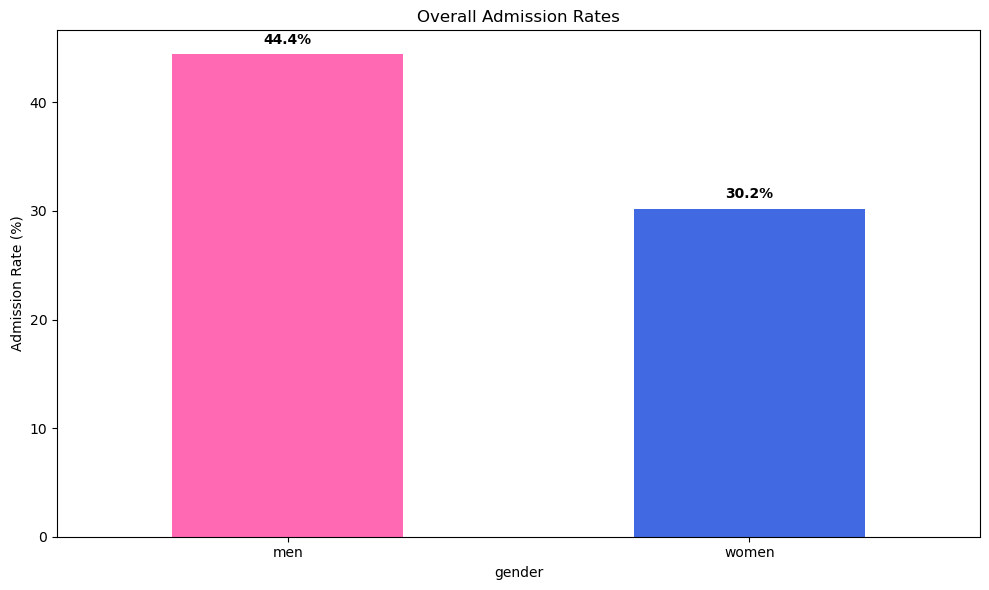

In [21]:

overall_rates['admission_rate'].plot(kind='bar', color=['#FF69B4', '#4169E1'], title='Overall Admission Rates', ylabel='Admission Rate (%)', figsize=(10, 6))
for i, v in enumerate(overall_rates['admission_rate']): plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout();
plt.show()


Women appear to be lower admission rate of 30.2% to men of 44.4 person

In [22]:
#Within-major rates

by_major = df.pivot_table(values='admitted', index='major', columns='gender', aggfunc='first')
print(by_major.round(2))

gender  men  women
major             
A        62     82
B        63     68
C        37     34
D        33     35
E        28     24
F         6      7


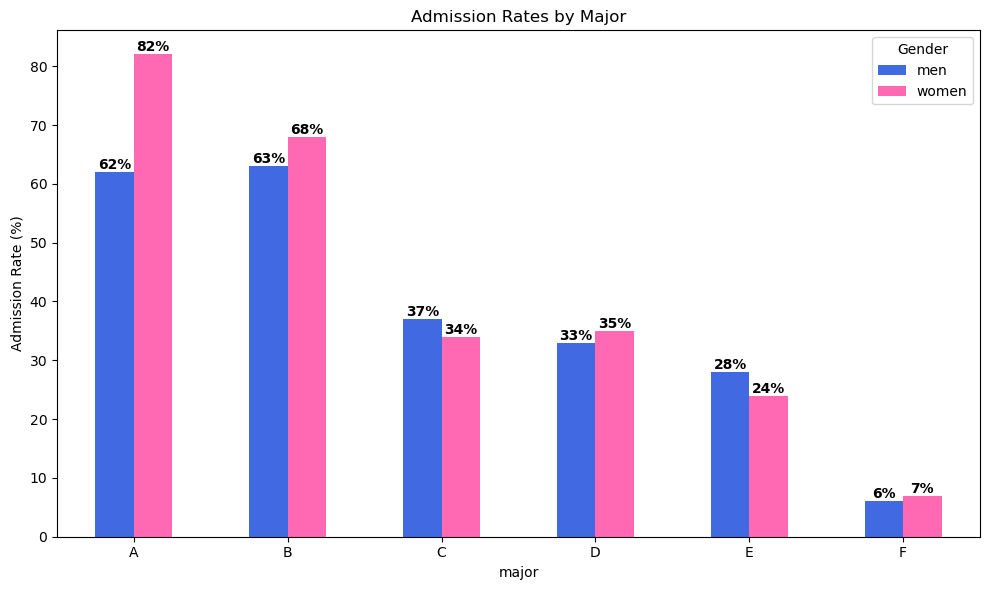

In [23]:
by_major.plot(kind='bar', color=['#4169E1', '#FF69B4'], title='Admission Rates by Major', ylabel='Admission Rate (%)', figsize=(10, 6))
for container in plt.gca().containers: plt.bar_label(container, fmt='%.0f%%', fontweight='bold')
plt.xticks(rotation=0); plt.legend(title='Gender')
plt.tight_layout();
plt.show()

In almost every major, women have higher or equal admission rates than men

In [24]:
#Percentage of applicants by gender

applicant_dist = df.pivot_table(values='applicants', index='major', columns='gender', aggfunc='first')
applicant_pct = applicant_dist.div(applicant_dist.sum()) * 100
print("Percentage of applicants by major:")
print(applicant_pct.round(2))

Percentage of applicants by major:
gender    men  women
major               
A       30.66   5.89
B       20.81   1.36
C       12.08  32.32
D       15.50  20.44
E        7.10  21.42
F       13.86  18.58


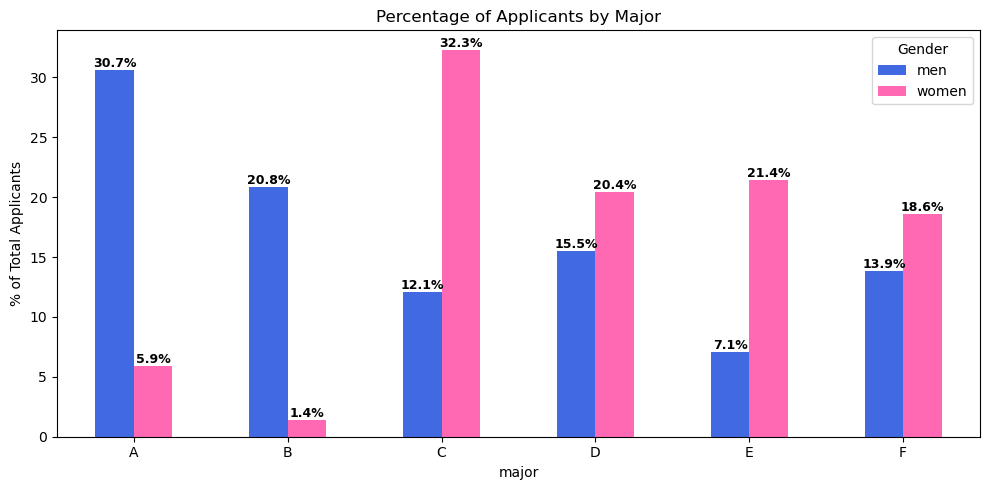

In [25]:
applicant_pct.plot(kind='bar', color=['#4169E1', '#FF69B4'], title='Percentage of Applicants by Major', ylabel='% of Total Applicants', figsize=(10, 5))
for container in plt.gca().containers: plt.bar_label(container, fmt='%.1f%%', fontweight='bold', fontsize=9)
plt.xticks(rotation=0); plt.legend(title='Gender')
plt.tight_layout();
plt.show()

In [26]:
#Major by difficulty
major_difficulty = df.groupby('major')['admitted'].mean().sort_values()
for major, rate in major_difficulty.items():
    print(f"  Major {major}: {rate:.1f}% admission rate")

  Major F: 6.5% admission rate
  Major E: 26.0% admission rate
  Major D: 34.0% admission rate
  Major C: 35.5% admission rate
  Major B: 65.5% admission rate
  Major A: 72.0% admission rate


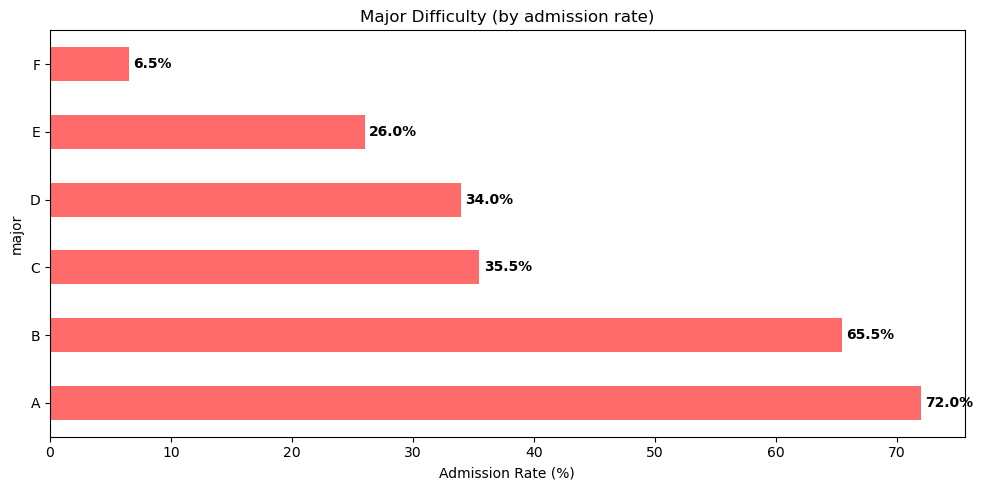

In [27]:
ax = major_difficulty.plot(kind='barh', color='#FF6B6B', title='Major Difficulty (by admission rate)', xlabel='Admission Rate (%)', figsize=(10, 5))
ax.bar_label(ax.containers[0], fmt='%.1f%%', fontweight='bold', padding=3)
ax.invert_yaxis()
plt.tight_layout(); plt.savefig('simple_major_difficulty.png', dpi=300, bbox_inches='tight'); plt.show()

Women concentrated in harder majors (C, E, F) which are harder to get while Men concentrated in easier majors (A, B)

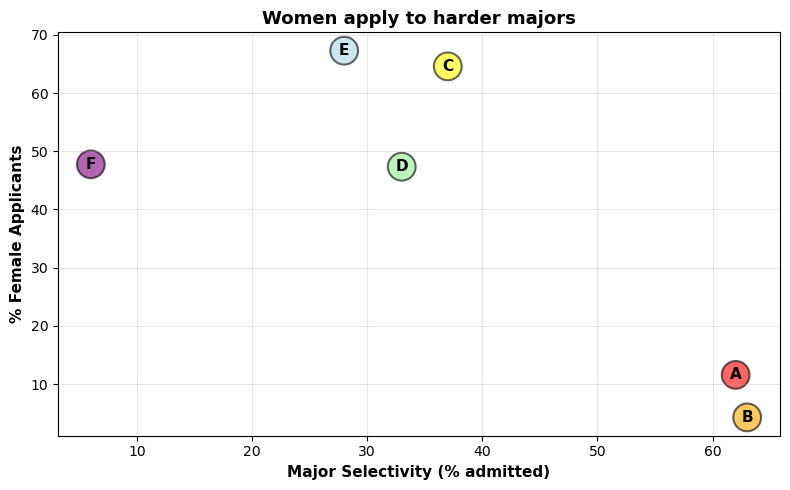

In [28]:
# Female concentration in difficulty major
major_stats = df.groupby('major').agg({'admitted': 'first', 'applicants': 'sum'})
female_pct = (df[df['gender'] == 'women'].set_index('major')['applicants'] / major_stats['applicants'] * 100)
plt.figure(figsize=(8, 5))
plt.scatter(major_stats['admitted'], female_pct, s=400, alpha=0.6, c=['red', 'orange', 'yellow', 'lightgreen', 'lightblue', 'purple'], edgecolor='black', linewidth=1.5)
for major in major_stats.index: plt.annotate(major, (major_stats.loc[major, 'admitted'], female_pct[major]), ha='center', va='center', fontweight='bold', fontsize=11)
plt.xlabel('Major Selectivity (% admitted)', fontsize=11, fontweight='bold'); plt.ylabel('% Female Applicants', fontsize=11, fontweight='bold'); 
plt.title('Women apply to harder majors', fontweight='bold', fontsize=13); 
plt.grid(True, alpha=0.3); plt.tight_layout(); 
plt.show()

Women are disproportionately concentrated in the most competitive majors, especially E, C, and D

In [29]:
#Regression with Fixed Effect
#Using Gender effect controlling major
# data preparation
reg = df.copy()
reg['is_female'] = (reg['gender'] == 'women').astype(int)
reg['major_effect_B'] = (reg['major'] == 'B').astype(int)
reg['major_effect_C'] = (reg['major'] == 'C').astype(int)
reg['major_effect_D'] = (reg['major'] == 'D').astype(int)
reg['major_effect_E'] = (reg['major'] == 'E').astype(int)
reg['major_effect_F'] = (reg['major'] == 'F').astype(int)

X = reg[['is_female', 'major_effect_B', 'major_effect_C', 'major_effect_D', 'major_effect_E', 'major_effect_F']]
X = sm.add_constant(X)
y = reg['admitted']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               admitted   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     26.80
Date:                Mon, 02 Mar 2026   Prob (F-statistic):            0.00119
Time:                        16:51:09   Log-Likelihood:                -33.624
No. Observations:                  12   AIC:                             81.25
Df Residuals:                       5   BIC:                             84.64
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             70.2500      4.717     14.

C:\Users\Mukaila Rafiu\AppData\Roaming\Python\Python313\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)


After controlling for major, women have 3.50% higher admission rate than men

In [30]:
#T-TEST
#Testing within-major differences to see if significant
men_rates = df[df['gender'] == 'men']['admitted'].values
women_rates = df[df['gender'] == 'women']['admitted'].values
t_stat, p_value = stats.ttest_ind(men_rates, women_rates)
print(f"\nT-test (men vs women admission rates across majors):")
print(f"  Men average: {men_rates.mean():.2f}%")
print(f"  Women average: {women_rates.mean():.2f}%")
print(f"  Difference: {women_rates.mean() - men_rates.mean():.2f} percentage points")
print(f"  T-statistic: {t_stat:.3f}")
print(f"  P-value: {p_value:.4f}")


T-test (men vs women admission rates across majors):
  Men average: 38.17%
  Women average: 41.67%
  Difference: 3.50 percentage points
  T-statistic: -0.242
  P-value: 0.8139


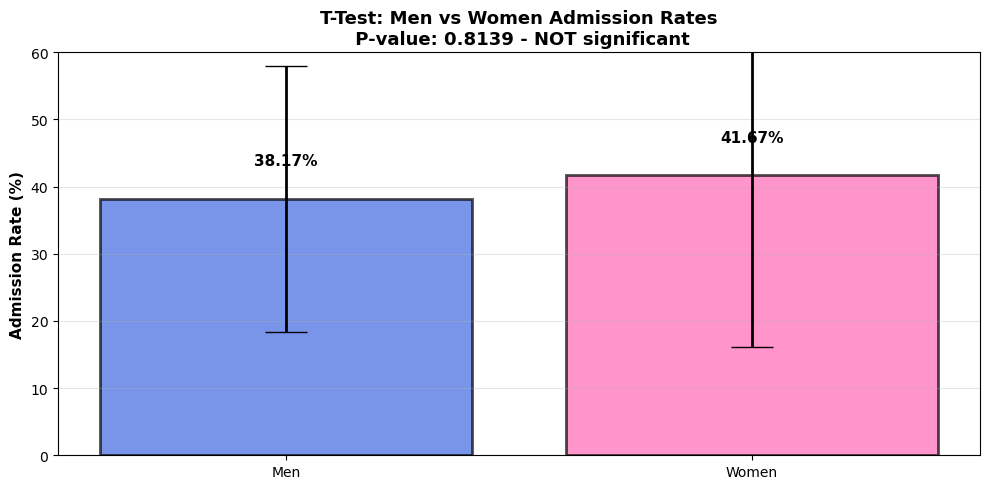

In [31]:
means = [men_rates.mean(), women_rates.mean()]
stds = [men_rates.std(), women_rates.std()]
plt.figure(figsize=(10, 5))
bars = plt.bar(['Men', 'Women'], means, yerr=stds, capsize=15, color=['#4169E1', '#FF69B4'], alpha=0.7, edgecolor='black', linewidth=2, error_kw={'linewidth': 2})
for bar, mean in zip(bars, means): plt.text(bar.get_x() + bar.get_width()/2, mean + 5, f'{mean:.2f}%', ha='center', fontweight='bold', fontsize=11)
plt.ylabel('Admission Rate (%)', fontsize=11, fontweight='bold'); plt.title(f'T-Test: Men vs Women Admission Rates\n P-value: {p_value:.4f} - NOT significant', 
fontweight='bold', fontsize=13); plt.ylim(0, 60); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); 
plt.show()

Although women have a 3.5 percentage point higher admission rate across majors, and the model explains 97% of the variation, the result is not statistically significant. This is largely due to the small sample size n = 12.
With fewer than 20 observations, the test lacks sufficient statistical power, making it difficult to obtain a small p-value even if a real difference truly exists.  

At first glance, the aggregate data suggest the presence of gender bias: 44.4% of men were admitted compared to 30.2% of women.
However, this apparent gap disappears once we control for major choice. Within the same majors, women are admitted at rates about 3.5 percentage points higher than their male counterparts, and in nearly all majors, women are admitted at equal or higher rates than men.
The overall disparity is instead driven by selection into majors. Women tend to apply disproportionately to more competitive majors, which have an average admission rate of 27.7%, while men are more concentrated in less competitive majors, where the average admission rate is 62.5%.
In short, the observed gender gap in overall admissions reflects selection bias, not discrimination.

In [32]:
#ROBUSTNESS CHECKS

- Weighted OLS by number of applicants
- Logistic Regression 
- Aggregate level of admission rates ignoring major

In [34]:
#Weighted OLS by number of applicants
robustness_results = {}
weighted = sm.WLS(y, X, weights=reg['applicants']).fit()
print(weighted.summary())
robustness_results['Weighted OLS'] = {
    'coef': weighted.params['is_female'],
    'se': weighted.bse['is_female'],
    'pval': weighted.pvalues['is_female']
}
print()

                            WLS Regression Results                            
Dep. Variable:               admitted   R-squared:                       0.978
Model:                            WLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     37.30
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           0.000539
Time:                        16:52:07   Log-Likelihood:                -31.843
No. Observations:                  12   AIC:                             77.69
Df Residuals:                       5   BIC:                             81.08
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             64.1125      2.993     21.

C:\Users\Mukaila Rafiu\AppData\Roaming\Python\Python313\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)


While weighted by the number of applicant, it still statistically not significant as the rest due to that sample size. The variation explainied by the model is 98% making the point estimate consistent with the baseline of 1.87, 
confirming the robustness of the finding that women have equal or slightly higher admission rates within majors. 

This contradicts the aggregate data, illustrating Simpson's Paradox: the apparent gender disadvantage 
at the aggregate level (women 30.2% vs men 44.4%) disappears when controlling for major selectivity, indicating that differential major selection rather than discrimination explains 
the aggregate disparity.

In [35]:
# Logistic Regression 
# Create binary indicator for gender (1 = female, 0 = male)
df['is_female'] = (df['gender'] == 'women').astype(int)
# Create dummy variables for major
major_dummies = pd.get_dummies(df['major'], prefix='major', drop_first=True)
df_prepared = pd.concat([df[['is_female', 'admitted_count', 'rejected_count']], major_dummies], axis=1)
data_list = []
for idx, row in df_prepared.iterrows():
    for _ in range(int(row['admitted_count'])):
        record = {'admitted': 1, 'is_female': row['is_female']}
        for col in major_dummies.columns:
            record[col] = row[col]
        data_list.append(record)
    for _ in range(int(row['rejected_count'])):
        record = {'admitted': 0, 'is_female': row['is_female']}
        for col in major_dummies.columns:
            record[col] = row[col]
        data_list.append(record)
df_expanded = pd.DataFrame(data_list)
feature_cols = ['is_female'] + list(major_dummies.columns)
X = df_expanded[feature_cols].values
y = df_expanded['admitted'].values

In [36]:
# Fit logistic regression
logit_model = LogisticRegression(fit_intercept=True, max_iter=1000)
logit_model.fit(X, y)
female_idx = 0
female_coef = logit_model.coef_[0][female_idx]
odds_ratio = np.exp(female_coef)
print(f"\nSample size: {len(df_expanded)} individuals")
print(f"Admitted: {y.sum()}, Rejected: {(1-y).sum()}")
print(f"\nLogistic Regression Results:")
print(f"Female Coefficient (log-odds): {female_coef:.4f}")
print(f"Odds Ratio: {odds_ratio:.4f}")


Sample size: 4526 individuals
Admitted: 1749, Rejected: 2777

Logistic Regression Results:
Female Coefficient (log-odds): 0.0704
Odds Ratio: 1.0730


Women are 7% more likely to be admitted than the men, matching the findings from OLS +1.87%, all confirming Simpson's Paradox

In [37]:
# Aggregate level of admission rates ignoring major
men_admitted = df[df['gender'] == 'men']['admitted_count'].sum()
men_total = df[df['gender'] == 'men']['applicants'].sum()
women_admitted = df[df['gender'] == 'women']['admitted_count'].sum()
women_total = df[df['gender'] == 'women']['applicants'].sum()
men_rate = (men_admitted / men_total) * 100
women_rate = (women_admitted / women_total) * 100
aggregate_diff = women_rate - men_rate
print(f"\nMen:     {men_admitted:4d} admitted / {men_total:4d} applicants = {men_rate:6.2f}%")
print(f"Women:   {women_admitted:4d} admitted / {women_total:4d} applicants = {women_rate:6.2f}%")
print(f"Difference: {aggregate_diff:+.2f} percentage points")


Men:     1195 admitted / 2691 applicants =  44.41%
Women:    554 admitted / 1835 applicants =  30.19%
Difference: -14.22 percentage points


Women are at disadvantage in overall admission rate. Holding major constant, woman have 14.22% points lower admission rate overall

Final remarks:
The robustness check confirms the initial findings and reinforces the conclusion that there is no evidence of gender bias in the admission process.